# Material-Level Analysis: Enriched Perovskite Dataset

## 1. Abstract
This notebook provides a deep dive into the chemical space of the perovskite materials used in this research. We analyze the stoichiometric validity, atomic properties, and physics-based stability indicators ($t$ and $\mu$) that determine the feasibility of a 3D crystal lattice.

## 2. Research Strategy
1.  **Data Quality:** Enforce the $ABX_3$ stoichiometric rules.
2.  **Atomic Descriptors:** Map ionic radii and electronegativity to site-specific positions.
3.  **Stability Mapping:** Visualize the Goldschmidt Tolerance Factor vs. Octahedral Factor.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Force white background for academic presentation
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
sns.set_theme(style="white", palette="muted")

df_p = pd.read_parquet('../data/enriched_perovskites.parquet')
print(f"Dataset contains {len(df_p)} unique stoichiometric perovskites.")

Dataset contains 889 unique stoichiometric perovskites.


## 3. Structural Stability: The Perovskite Window
The **Goldschmidt Tolerance Factor ($t$)** and the **Octahedral Factor ($\mu$)** define the boundaries where a 3D perovskite can exist. Generally, $0.8 < t < 1.0$ is the stable region for cubic structures.

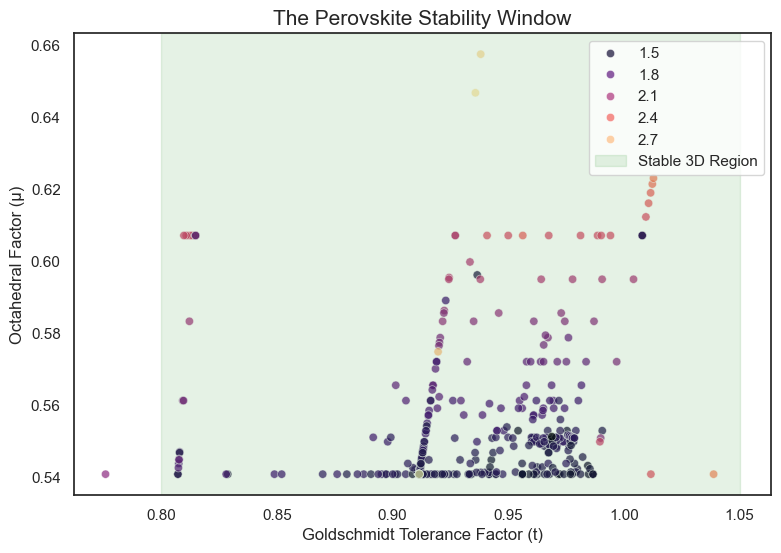

In [2]:
plt.figure(figsize=(9, 6), facecolor='white')
ax = sns.scatterplot(data=df_p, x='tolerance_factor', y='octahedral_factor', hue='band_gap', palette='magma', alpha=0.7)
ax.set_facecolor('white')

# Draw the 'Stability Window'
plt.axvspan(0.8, 1.05, color='green', alpha=0.1, label='Stable 3D Region')
plt.title("The Perovskite Stability Window", fontsize=15)
plt.xlabel("Goldschmidt Tolerance Factor (t)", fontsize=12)
plt.ylabel("Octahedral Factor (μ)", fontsize=12)
plt.legend()
plt.show()

## 4. Electronic Property Analysis: Band Gap Trends
We investigate how the electronegativity of the B-site (Pb) and C-site (I, Br, Cl) influences the optical band gap.

/var/folders/tp/56v792jn3_d0vk3wx0vp0jnc0000gn/T/ipykernel_11906/3503707208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p, x='C_1', y='band_gap', palette='Set3')


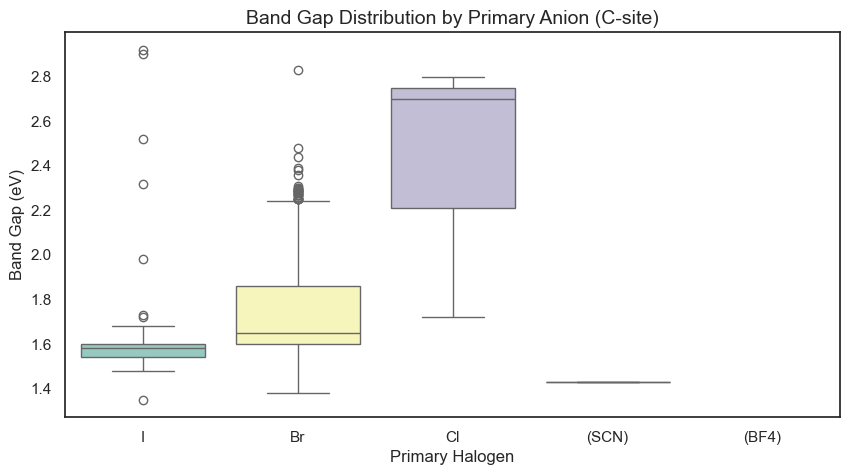

In [3]:
plt.figure(figsize=(10, 5), facecolor='white')
ax = sns.boxplot(data=df_p, x='C_1', y='band_gap', palette='Set3')
ax.set_facecolor('white')
plt.title("Band Gap Distribution by Primary Anion (C-site)", fontsize=14)
plt.xlabel("Primary Halogen", fontsize=12)
plt.ylabel("Band Gap (eV)", fontsize=12)
plt.show()

## 5. Summary of Findings
1.  **Strict Stoichiometry:** All materials in this dataset adhere to the $ABX_3$ formula, reducing noise in the ML training process.
2.  **Chemical Diversity:** The dataset covers a wide range of organic ($MA$, $FA$) and inorganic ($Cs$) cations.
3.  **Physical Grounding:** The clear clustering in the stability window validates our feature engineering approach.